## Rating and Location Data Analysis Notebook

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../Data/clean/airbnb_cleaned.csv")

print(df.head())
print(df.info())

                                             title        lat        lng  \
0  ETERNA.Suite W Jaccuzi, Pyramids View & Balcony  29.973873  31.146603   
1                                 king khufu suite  29.986300  31.143100   
2                             Akasia Pyramids View  29.978100  31.145400   
3          Mountain Cave | Pyramids View & Jacuzzi  29.979090  31.146920   
4                               Heaven of Pyramids  29.978787  31.144191   

   rating_overall  reviews_count  rating_accuracy  rating_cleanliness  \
0            4.95          133.0             4.96                4.92   
1            5.00           62.0             5.00                5.00   
2            4.91          176.0             4.91                4.91   
3            4.92           12.0             5.00                4.75   
4            4.71          125.0             4.74                4.61   

   rating_value  rating_location  price_breakdown_baseprice_price  ...  \
0          4.92             4.

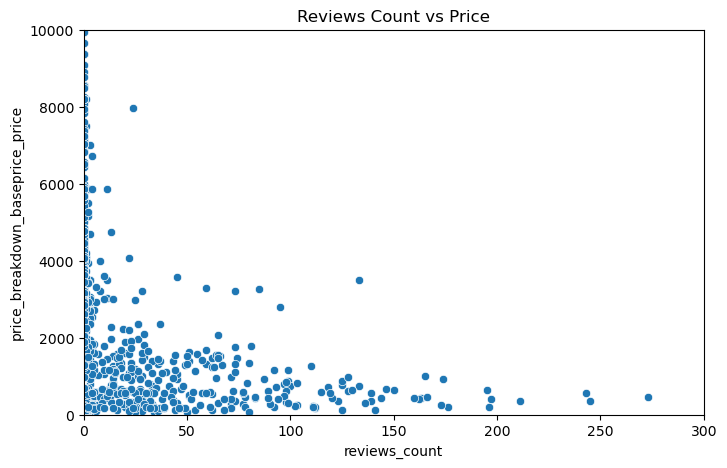

In [12]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['reviews_count'], y=df['price_breakdown_baseprice_price'])
plt.xlim(0, 300)
plt.ylim(0, 10000)
plt.title("Reviews Count vs Price")
plt.savefig("Plots/price_vs_reviews.png")
plt.show()

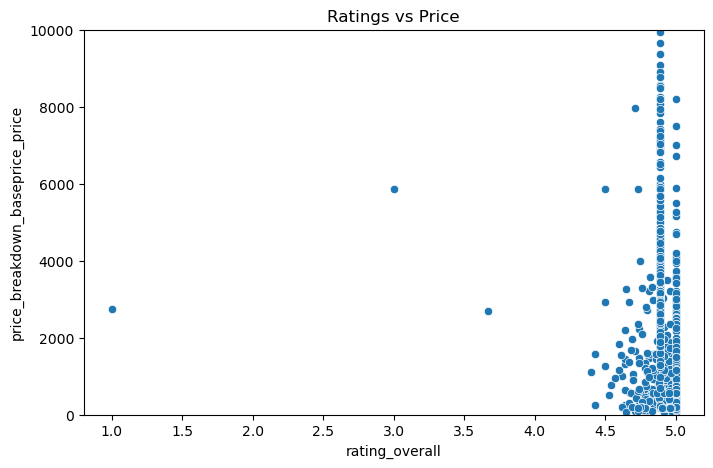

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['rating_overall'], y=df['price_breakdown_baseprice_price'])
plt.ylim(0, 10000)
plt.title("Ratings vs Price")
plt.savefig("Plots/price_vs_ratings.png")
plt.show()

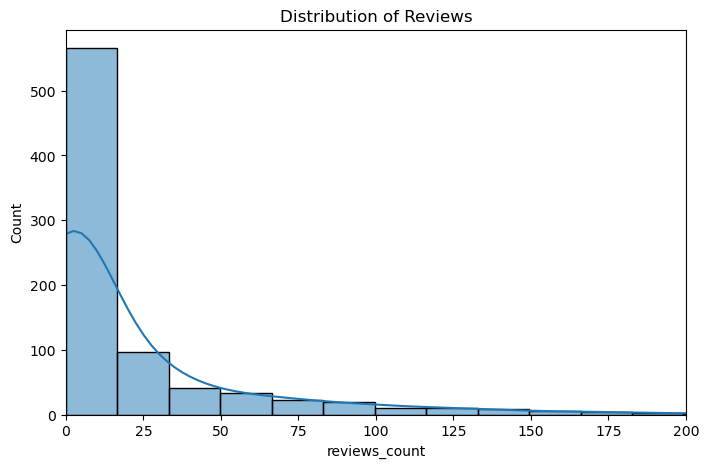

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['reviews_count'], bins=30, kde=True)
plt.xlim(0, 200)
plt.title("Distribution of Reviews")
plt.savefig("Plots/reviews_distribution.png")
plt.show()

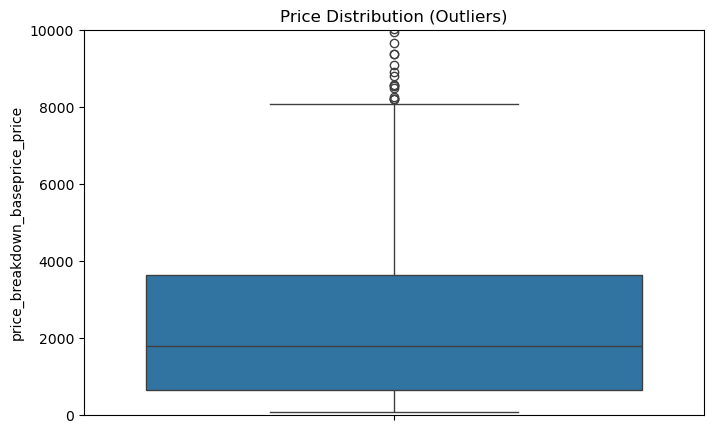

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df['price_breakdown_baseprice_price'])
plt.ylim(0, 10000)
plt.title("Price Distribution (Outliers)")
plt.savefig("Plots/price_distribution.png")
plt.show()

In [16]:
import folium
from folium.plugins import HeatMap

# Create base map
m = folium.Map(location=[df['lat'].mean(), df['lng'].mean()], zoom_start=12)

# --- Price layer ---
price_group = folium.FeatureGroup(name="Price Heatmap")
heat_price = list(zip(df['lat'], df['lng'], df['price_breakdown_baseprice_price']))
HeatMap(heat_price, radius=15, blur=10, max_zoom=13).add_to(price_group)
price_group.add_to(m)

# --- Reviews layer ---
reviews_group = folium.FeatureGroup(name="Reviews Heatmap", show=False)
heat_reviews = list(zip(df['lat'], df['lng'], df['reviews_count']))
HeatMap(heat_reviews, radius=15, blur=10, max_zoom=13).add_to(reviews_group)
reviews_group.add_to(m)

# --- Toggle control ---
folium.LayerControl().add_to(m)

m